So we learn about linear Regression now we learn the polynomial linear Regression

We already know
In simple linear regresion          
we have input and ouput varible .           
2d dim data             
X   |   Y           
.....           
                        
$y = mx + b$
$Y = B_0 + B_1X$                
In general form             
In Multiple Linear Regression           
We have multiple input and output variable          
n dim data              
X1,X2,  ..... Xn | Y  
.....               
        
                      
$Y = B_0 + B_1X_1+ B_2X_2 + ... B_nX_n$  

In [ ]:
# lakin yadi apka data linear na ho aor us par line fix karo
# ya par linear regression fail hota ha matlab acha results nahi ata
#

 so we use polynomial regression 
 sab kuch same ha baas data ma hum polymonimal terms add kar raha . data ma 
 important concept ya abhi parameters ma linear ha lakin hum sirf input col/varible ma polynomial term add kar raha ha 

X   |   Y           
.....           
Example apka isma polynoimal degree 2 ka bana  ha =
$x^0,x^1,x^2$           
example yadi first row in data ha 2 | y             
so    $2^0,2^1,2^2,y$      
our new row    $1,2 ,4 , y$  

now aap apna new row data ko training ka liya bajta ho
aap ya              
$x^n =x^0,x^1,x^2,... $          
polynomial terms apka data ka andr non-linear relationship ka model karta ha 

Now formula of simple linear polynomial regression of degree 2        
$Y = $Y = B_0 + B_1X+ B_2X^2 $ 

if degree is 3           
so $Y = B_0 + B_1X+ B_2X^2 + B_3X^3$ 

if polynomial degree is n               
so $Y = B_0 + B_1X+ B_2X^2 + B_3X^3 + ... B_nX^n$ 

Question : ya kesa pata chalaga ki degree ka value kiya set karna ha             
Answer : kyuki ya ek hyperparameter aor ya huma set karna hota ha 
ya data scientist ka kam ha ki vo sahi value choose kara            


yadi aap polynomial degree value kam rako tho `underfit` ka jaya            
yadi aap polynomial degree value jada rako tho `Overfit` ho jaya            
tho apko bitch ma koi optimum value nikal na padta ha 

yadi mera pass two columns ha               
X1 | X2 | Y             
....            
tho ek equation X1 or add the  equation X2 ka liya            
$Y = B_0 + B_1X+ B_2X^2 + B_3X_2 + B_4X_2^2$ 

Question : Why it is poylnomial linear regression 
Answer : deko X | Y  ya data tho hamra pass hota ha lakin huma $Y = BX ..$ input or ouput ka bitch ma relationship find kar rha using coefficients  tho Y and B ka bitch relationship is still is linear 

- now we generate a non linear data 
- and we fit the linear regresion - results acha nahi aa rha 
- and we fit the polyonomial linear regression on it - results acha aa raha ha choti degree sa badi degree tak

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression ,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

$y = 0.8^2 + 0.9x + 2$

# generate random data

Text(0, 0.5, 'y')

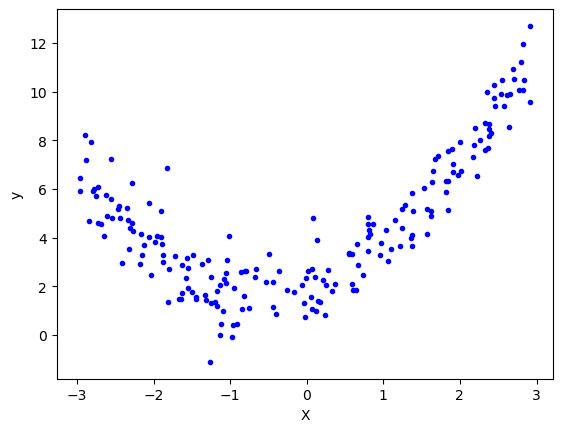

In [18]:
np.random.seed(42)
n_samples = 100
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')

## train test split

In [19]:
X_train,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [20]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(160, 1)
(160, 1)
(40, 1)
(40, 1)


## fit linear model

In [21]:
linear_model = LinearRegression()
linear_model.fit(X,y)

LinearRegression()

## calculate r2 score

In [24]:
y_pred = linear_model.predict(X_test)
print('r2_score :',r2_score(y_test,y_pred))

r2_score : 0.34509361755910084


ya bhut acha nahi ha 

## plot 
the linear regression line and our data 

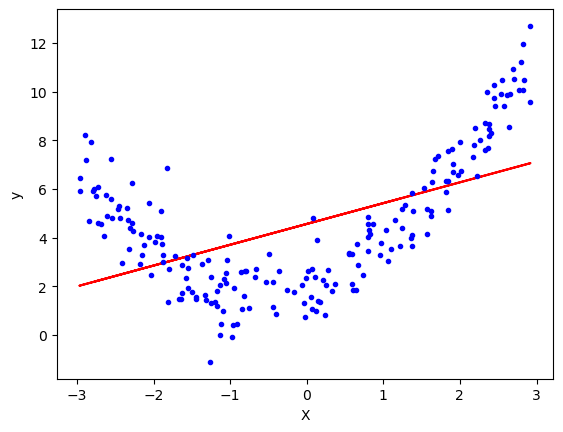

In [23]:
plt.plot(X_train,linear_model.predict(X_train),color = 'r')
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

Is data ka liya hamra linear line tik tarika sa kam nahi kar raha 

Deko hamra data non -linear ha aor aap usa justify karna ki koshish kar raha ho using linear line tho vo sahi cheez nahi ha 

# apply poylnomial linear regression 

In [25]:
# apply polynomial linear Regression of degree 2
# huma apna features input columns ko transform karna hoga 
poly = PolynomialFeatures(degree=2)

X_train_transform = poly.fit_transform(X_train)
X_test_transform = poly.fit_transform(X_test)

yadi mera input ma 1 column ha tho muja transform input ma 3 column milaga              
so input col is $x$               
so transform input col is $x^0,x^1,x^2$             

In [ ]:
print(X_train[0])    # orginal data
print(X_test_transform[0])  # transform data

[1.21811375]
[1.         2.57818591 6.64704261]


Important :
Aap Transformation sirf X yani input ka upar apply karta ho Y ouptut ka upar apply nahi karta       
lakin dhyana ki input ma train and test dono par transoformation apply karna ha 

 yadi aap parmeter `inculde bias = false` karo ga tho apko $x^0$ nahi mila only $x^1,x^2$ milga 
 tho apna intercept bias wala terma ata diya 

In [27]:
poly = PolynomialFeatures(degree=2,include_bias=False)

X_train_transform = poly.fit_transform(X_train)
X_test_transform = poly.fit_transform(X_test)
print(X_train[0])    # orginal data
print(X_test_transform[0])  # transform data

[1.21811375]
[2.57818591 6.64704261]


In [28]:
# lakin hum abhi isa true kar raha ha 
poly = PolynomialFeatures(degree=2,include_bias=True)

X_train_transform = poly.fit_transform(X_train)
X_test_transform = poly.fit_transform(X_test)
print(X_train[0])    # orginal data
print(X_test_transform[0])  # transform data

[1.21811375]
[1.         2.57818591 6.64704261]


## again fit linear regression

In [33]:
model = LinearRegression()
model.fit(X_train_transform,y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test_transform)
print('r2_score',r2_score(y_test,y_pred))

r2_score 0.841416692467932


wow r2 score kitna jada improve kar gaya it  expalin 84% of varience in the data .

In [35]:
print('intercept :',model.intercept_)
print('coeffficnet :',model.coef_)

intercept : [1.96595528]
coeffficnet : [[0.         0.87874406 0.83625305]]


$Y = $Y = B_0 + B_1X+ B_2X^2 $          


Compare a table of orginal genrate vs predicated model parameter values

In [48]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = model.predict(X_new_poly)

## graph

### on training data

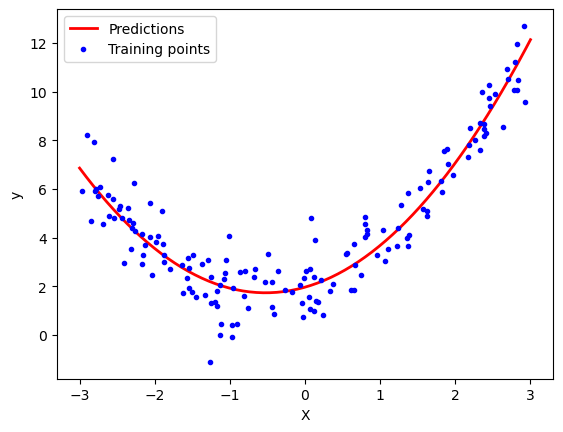

In [52]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
#plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### on Testing data

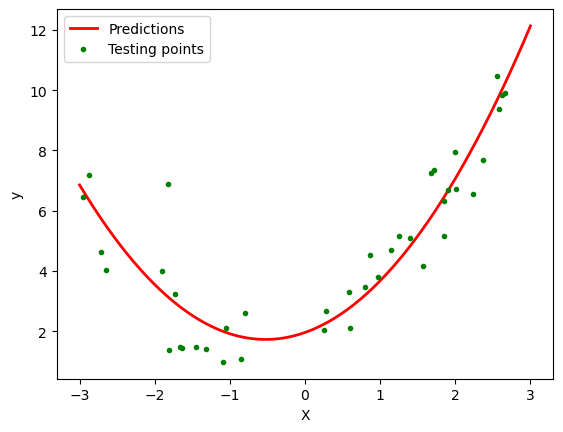

In [54]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
#plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### both on training and testing dat

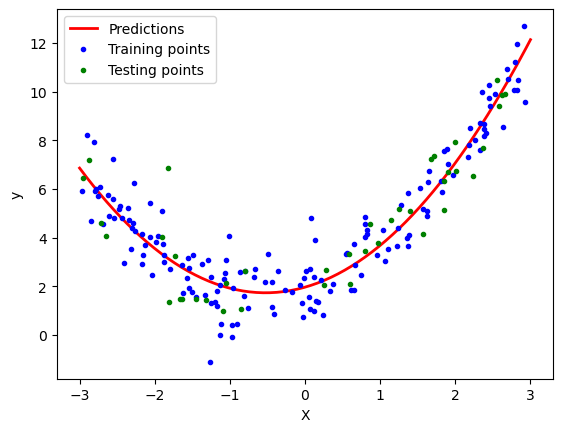

In [50]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# our polynomial function 
yadi hum degree of polynomial change karega tho dek payega

In [55]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

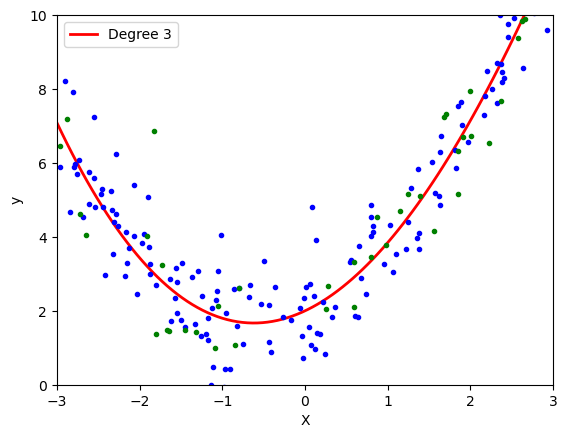

In [ ]:
# lets try different degree of polynomial
polynomial_regression(degree=3)

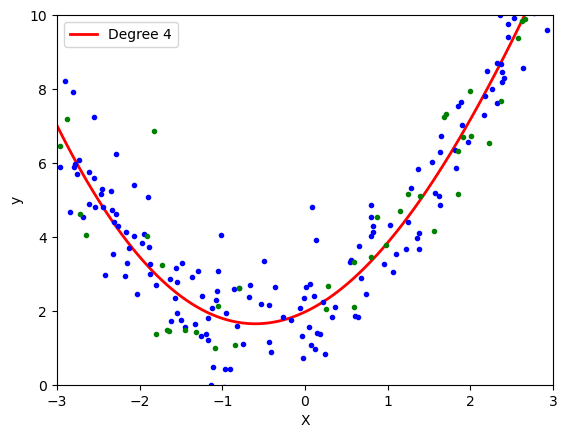

In [57]:
polynomial_regression(degree=4)

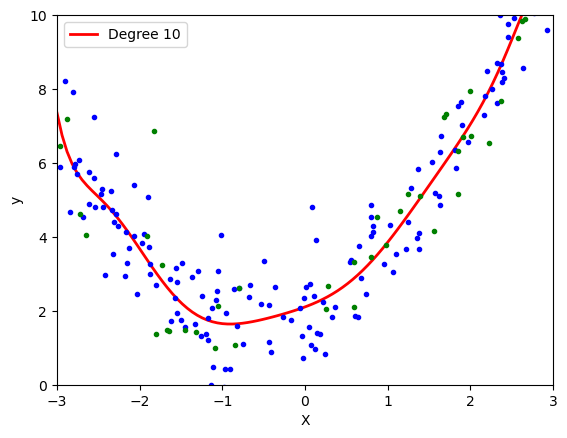

In [ ]:
polynomial_regression(degree=10)
# now thoda irregular behaviour hona shuru ho gaya ha 

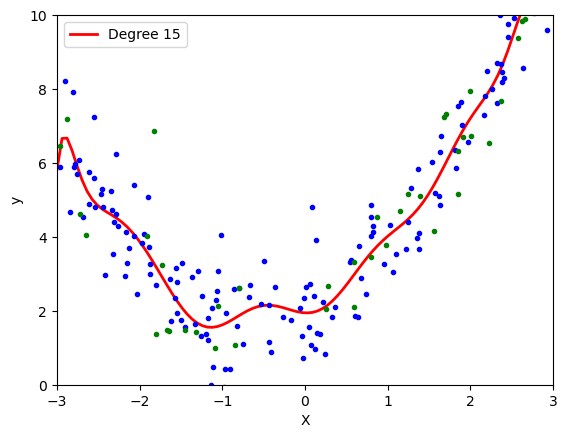

In [59]:
polynomial_regression(degree=15)

deko yadi hamra training data ma thoda bhi movement ha tho hamra polynomial regression usa capture karna ki koshish kar raha ha 

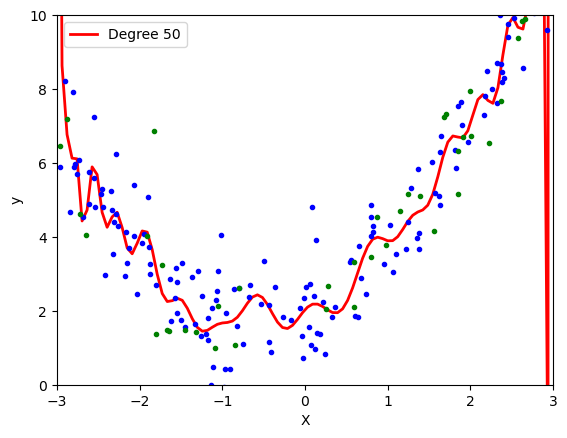

In [69]:
polynomial_regression(degree=50)

ab ya data ma pattern sikana ka bayaga una ratna ki koshish kar raha ha 

ab apka model generalise nahi karega .
maltab apka model training data ko jada value kar ha . na ki testing data ko yani bule wala points par jada dhyan da green wala points ma dhyan da nahi raha  

isa overfitinga bolta ha . makes sure jab bhi aap polynomial degree laga raha ho use correct degree for it

# Interactive function
change the degree of polynomial and see the effect 

In [62]:
import ipywidgets as widgets

In [67]:
def polynomial_regression(degree= 1):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

In [ ]:
widgets.interact(polynomial_regression,degree =(1,25,1))

interactive(children=(IntSlider(value=1, description='degree', max=25, min=1), Output()), _dom_classes=('widge…

<function __main__.polynomial_regression(degree=1)>

Jab bhi aap polynomial regression laga raha ho apka sahi degreee choose karna yadi aap 2d case ma dek raha tho vo graph plot karka ayega
yadi jada number of columns ha tho cross valiation score yani r2 score dekna sa pata chalega  ek do graph aor hota ha  jasa learning curve una dek kar samaj aa jata ki muja kitna number of degree chaya 

Learnings 
- if polynomial degree is low = underfitting          
- if polynomial degreee is hight = Overfitting 

if polynomial degree is low = underfitting      
na training data par patterns khoj pata ha  na hi test data par             
if polynomial degreee is high = Overfitting            
then apka model training data ko bhut jada value karna lag jata ha chota chota patterns ko bhi pakadna lag jata ha yadi test data ma vo patterns nahi hua tho score kharab ho jayega 

tho hamra data par optimum degreee ha 2 .           
kyuki starting ma hamana generation hi degree 2 sa kiya tha                 
lakin aga jab aap real data par kam karoga              
tho apko underlying equation pata nahi hogi .           

Now hamna sika for simple polynomial regression one input one ouput 

yadi hamra pass multiple input one output  tho we use multiple polynomial regression 

# Multiple polynomial regression 

Our data generation equation             
$z = x^2 +y^2 + 0.2x +0.2y + 0.1xy + 2 $

In [71]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [76]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.update_layout(width=700,height=700,title_text = '3d scatter parabola')
fig.show()

Now we first apply the multiple linear regression on the data 
ek plan ka through isko map kareaga 

In [73]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)



In [77]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))
fig.update_layout(width=700,height=700,title_text = '3d scatter parabola')

fig.show()

Deko data ma non-linearity ha aor aap ek surface sa usa model karna chata ha 

apply polynomial features 

In [78]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [80]:
poly = PolynomialFeatures(degree=2)
X_multi_trans = poly.fit_transform(X_multi)

In [82]:
print('input features', poly.n_features_in_)
print('ouput features',poly.n_output_features_)


input features 2
ouput features 6


In [83]:
# Question : how it extract 6 featues
# using the rule

print('Power\n',poly.powers_)

Power
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


tho ya hamna bachpan ma ths ma pada tha 

$ x_1^0,x_2^0 $ constant term        
$ x_1^1,x_2^0 $  x1 ki power 1 and x2 ki power 0 wala      
$ x_1^2,x_2^0 $        
$ x_1^1,x_2^1 $        
$ x_1^0,x_2^2 $        
        

question : dono ka 2 wala term kyu nahi ?               
yadi apna vo kiya tho total polynomial degree 4 ho jayega                   
2 pol degree from first col and 2 pol degree from second col                
concept dono ka mila kara polynmila degeee 2 ya 2 sa kam hona chaya              


In [84]:
X_multi_trans.shape

(100, 6)

In [85]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [ ]:
X_test_multi = poly.transform(final)
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [87]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(width=700,height=700,title_text = '3d scatter parabola',scene = dict(zaxis = dict(range=[0,35])))

fig.show()

In [92]:
# now change number of degree and see the graph 

def multiple_dim_polynomial(degree=2):
    poly = PolynomialFeatures(degree)
    X_multi_trans = poly.fit_transform(X_multi)
    lr = LinearRegression()
    lr.fit(X_multi_trans,z)
    X_test_multi = poly.transform(final)
    z_final = lr.predict(X_multi_trans).reshape(10,10)
    fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

    fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

    fig.update_layout(width=700,height=700,title_text = '3d scatter parabola',scene = dict(zaxis = dict(range=[0,35])))

    fig.show()
multiple_dim_polynomial()

now change the degee and see the effect

In [ ]:
widgets.interact(multiple_dim_polynomial,degree =(2,25,1))

interactive(children=(IntSlider(value=2, description='degree', max=25, min=2), Output()), _dom_classes=('widge…

<function __main__.multiple_dim_polynomial(degree=2)>